In [16]:
# Steel model

import numpy as np
import matplotlib.pyplot as plt

from resource_model import ResourceModel
from const import (CLASS_TO_REGION_DICT, REGION_TO_CLASS_DICT, 
                   path_input_data, all_regions_list_class)

In [17]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)



steel_grouping = {'all': all_regions_list_class[:-1]}

steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()

In [18]:
# Share of IAMGE MAT data to total consumption
(steel.image_mat_data/steel.historic_consumption_data*100).mean()

class_ 1      38.789879
class_ 10     35.577160
class_ 11     36.247884
class_ 12     28.966724
class_ 13     56.218331
class_ 14     19.468454
class_ 15     46.209403
class_ 16     20.178790
class_ 17     81.802333
class_ 18     77.023622
class_ 19     26.648454
class_ 2      41.464390
class_ 20     61.064043
class_ 21     58.360933
class_ 22    169.272387
class_ 23     27.905369
class_ 24     45.778686
class_ 25    437.433546
class_ 26    729.795254
class_ 3      54.261956
class_ 4     235.175057
class_ 5      65.600568
class_ 6      69.668400
class_ 7      62.183248
class_ 8     419.581561
class_ 9            inf
dtype: float64

<Axes: >

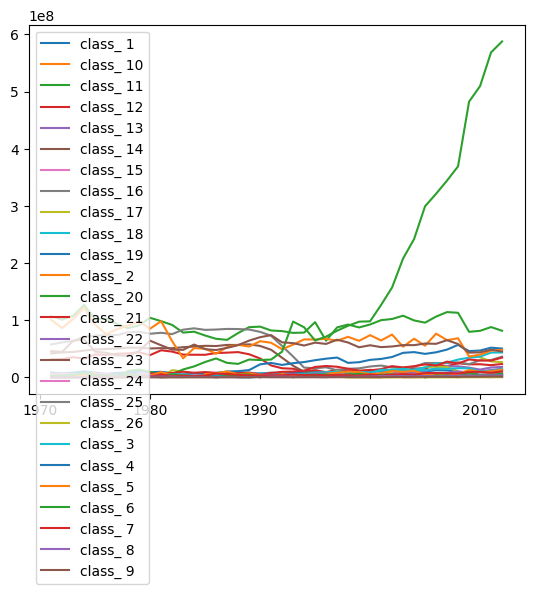

In [19]:
# deal with regions where there are negative values because consumption was lower than mat projections
steel.historic_other_fraction_consumption[['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']]

# too many negative: class 4, 8, 9, 22, 25, 26
# assumption: IMAGE MATERIALS is overestimating, 
# real consumption numbers are true & 
# TODO: MATERIALS calculations should be scaled down accordingly 
neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan

# Plot
steel.historic_other_fraction_consumption.plot()

In [20]:

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)
steel.fit_models()

# Best models
steel.best_rmse_models
steel.merged_rmse_r2

# project based on best model
steel.project_on_total(all_regions_list_class[:-1], 
                        REGION_TO_CLASS_DICT,
                        steel.gdp_pc_100)

all


<Axes: >

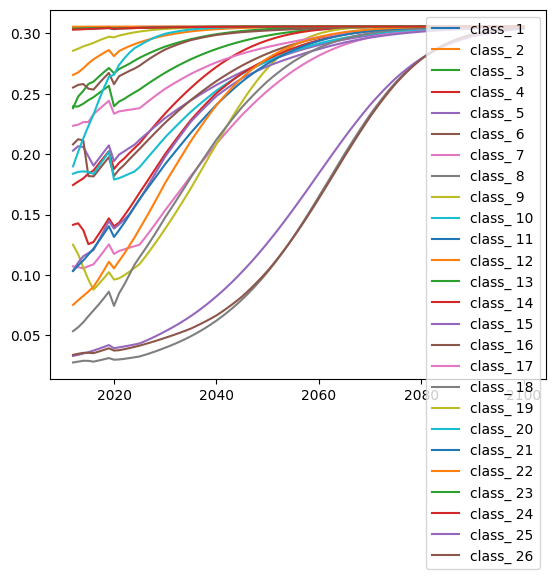

In [21]:
steel.projection_per_region.plot()

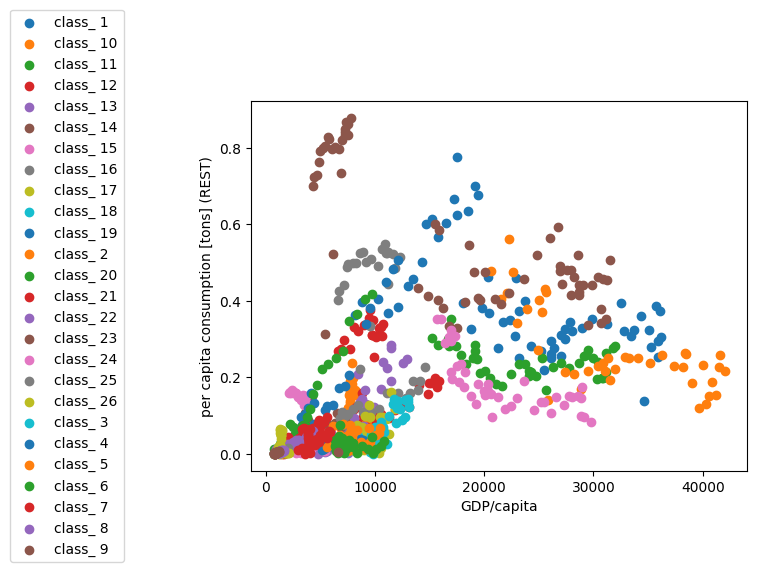

: 

In [ ]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], label = region)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))